### Task B: Create a bipartite network with the above data – If the network looks too dense, make it difficult to make connections, so that the network can be analyzed efficiently using tools like networkx. Show the visualization of the network.

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
import random

In [7]:
import pandas as pd

#df = pd.read_csv("/Users/radha/Desktop/MSBA/MSBA Spring/Social Media Analytics/Assignment2/goodreads_data.csv")

df.columns
df.head()

# Average reviewers per book
reviewers_per_book = df.groupby("book_title")["reviewer_id"].nunique()

avg_reviewers = reviewers_per_book.mean()

print("Rows:", len(df))
print("Unique books:", df["book_title"].nunique())
print("Unique reviewers:", df["reviewer_id"].nunique())
print("Average reviewers per book:", round(avg_reviewers, 2))
print("Min reviewers per book:", reviewers_per_book.min())
print("Median reviewers per book:", reviewers_per_book.median())
print("Max reviewers per book:", reviewers_per_book.max())

Rows: 62655
Unique books: 419
Unique reviewers: 47575
Average reviewers per book: 149.53
Min reviewers per book: 125
Median reviewers per book: 150.0
Max reviewers per book: 150


### B1) Load the Scraped File + Basic Quality Checks

In [6]:
import pandas as pd
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
  # Assuming the uploaded file is a CSV, read it into a pandas DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  print(f"Successfully loaded {fn} into DataFrame.")
  break # Assuming only one file is uploaded or we only care about the first one

display(df.head())

Saving goodreads_data.csv to goodreads_data.csv
User uploaded file "goodreads_data.csv" with length 11882848 bytes
Successfully loaded goodreads_data.csv into DataFrame.


,genre,book_title,book_url,reviewer_id
0,fantasy,"Fantasy Lover (Hunter Legends, #1)",https://www.goodreads.com/book/show/84136.Fant...,27680861
1,fantasy,"Fantasy Lover (Hunter Legends, #1)",https://www.goodreads.com/book/show/84136.Fant...,3036523
2,fantasy,"Fantasy Lover (Hunter Legends, #1)",https://www.goodreads.com/book/show/84136.Fant...,1739253
3,fantasy,"Fantasy Lover (Hunter Legends, #1)",https://www.goodreads.com/book/show/84136.Fant...,30033395
4,fantasy,"Fantasy Lover (Hunter Legends, #1)",https://www.goodreads.com/book/show/84136.Fant...,603311


### B2) Build the Bipartite Graph (NetworkX)

In [8]:
B = nx.Graph()

# Add book nodes
books = df["book_title"].unique()
B.add_nodes_from(books, bipartite="book")

# Add user nodes
users = df["reviewer_id"].astype(str).unique()
B.add_nodes_from(users, bipartite="user")

# Add edges (user-book)
edges = list(zip(df["reviewer_id"].astype(str), df["book_title"]))
B.add_edges_from(edges)

print("Graph nodes:", B.number_of_nodes())
print("Graph edges:", B.number_of_edges())

Graph nodes: 47994
Graph edges: 62655


### B3) Compute Density/Complexity Stats (to judge if too dense)

In [9]:
num_users = len(users)
num_books = len(books)
num_edges = B.number_of_edges()

print("Users:", num_users)
print("Books:", num_books)
print("Edges:", num_edges)

# Degree stats
book_degrees = [B.degree(b) for b in books]
user_degrees = [B.degree(u) for u in users]

print("Book degree (min/median/max):",
      min(book_degrees), pd.Series(book_degrees).median(), max(book_degrees))

print("User degree (min/median/max):",
      min(user_degrees), pd.Series(user_degrees).median(), max(user_degrees))

Users: 47575
Books: 419
Edges: 62655
Book degree (min/median/max): 125 150.0 150
User degree (min/median/max): 1 1.0 32


### B4) If Network Looks Too Dense, Make It Efficient (Sparsification)

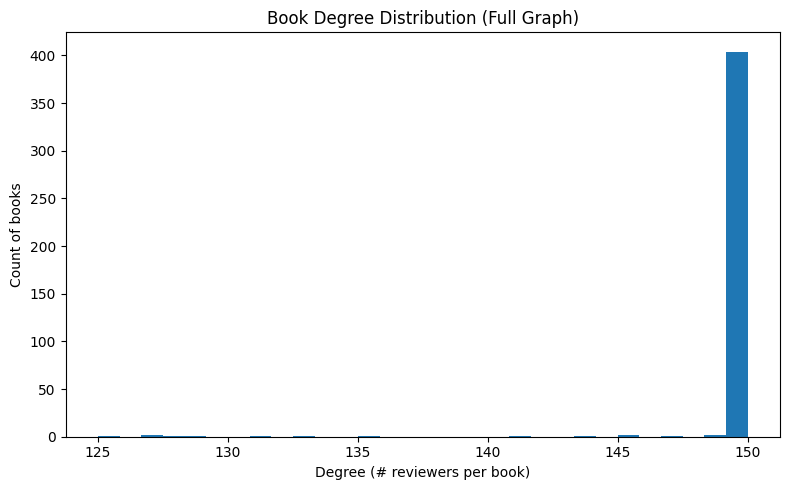

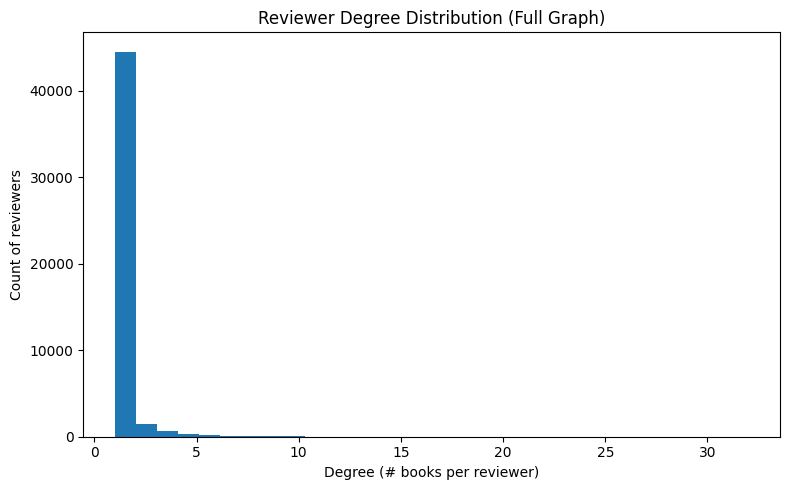

In [10]:
# --- 1) Degree distribution graphs (Full graph) ---
plt.figure(figsize=(8,5))
plt.hist(book_degrees, bins=30)
plt.title("Book Degree Distribution (Full Graph)")
plt.xlabel("Degree (# reviewers per book)")
plt.ylabel("Count of books")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(user_degrees, bins=30)
plt.title("Reviewer Degree Distribution (Full Graph)")
plt.xlabel("Degree (# books per reviewer)")
plt.ylabel("Count of reviewers")
plt.tight_layout()
plt.show()

### B5) Create a Visualization Subgraph (Sample 30–60 books)

In [11]:
# --- 2) Sparsification: sample N books + include all connected reviewers ---
def sample_books_subgraph(B, book_nodes, n_books=30, seed=7):
    random.seed(seed)
    sampled_books = random.sample(list(book_nodes), min(n_books, len(book_nodes)))

    sampled_users = set()
    for b in sampled_books:
        sampled_users.update(B.neighbors(b))

    keep_nodes = set(sampled_books) | set(sampled_users)
    subB = B.subgraph(keep_nodes).copy()
    return subB, sampled_books, list(sampled_users)

subB, sampled_books, sampled_users = sample_books_subgraph(B, books, n_books=30, seed=7)

print("\nSubgraph for visualization:")
print("Sampled books:", len(sampled_books))
print("Connected reviewers:", len(sampled_users))
print("Subgraph nodes:", subB.number_of_nodes())
print("Subgraph edges:", subB.number_of_edges())


Subgraph for visualization:
Sampled books: 30
Connected reviewers: 4332
Subgraph nodes: 4362
Subgraph edges: 4477


### B6) Visualize the Bipartite Graph

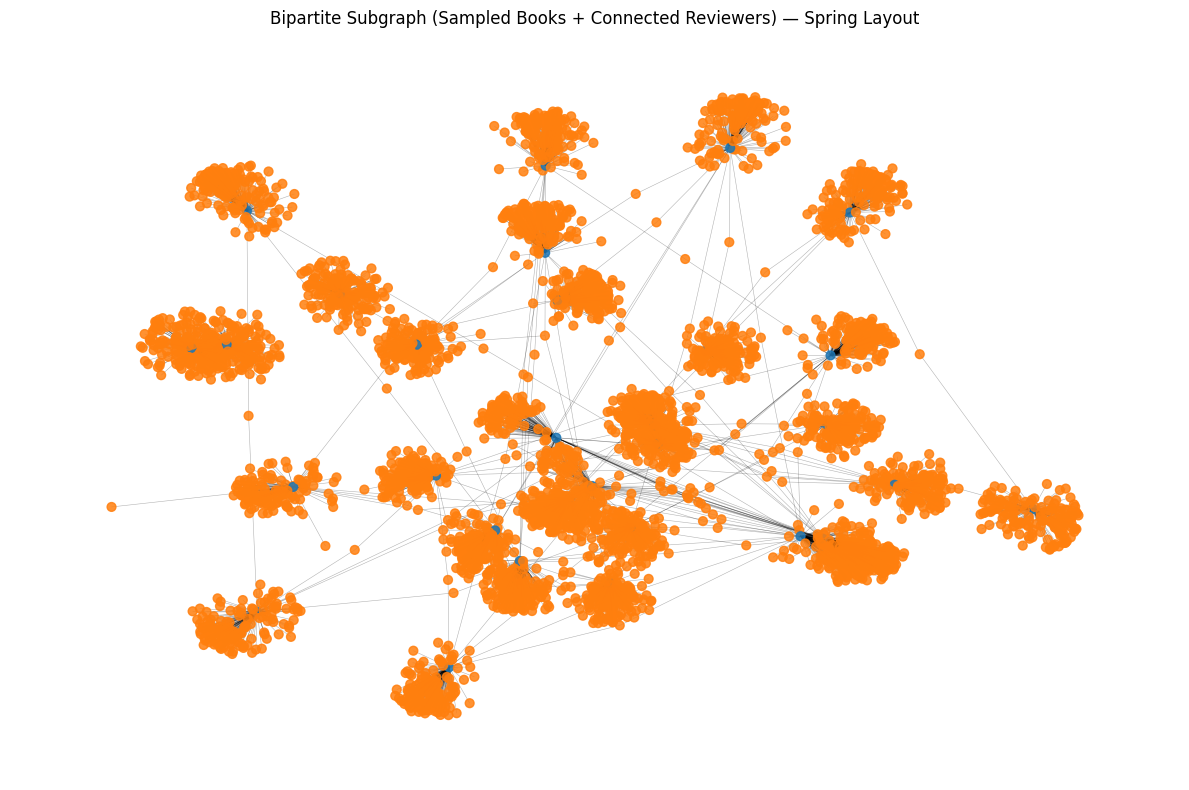

In [12]:
# --- 3) Visualize the sampled bipartite subgraph (Spring layout) ---
plt.figure(figsize=(12,8))

book_set = set(sampled_books)
node_colors = ["tab:blue" if n in book_set else "tab:orange" for n in subB.nodes()]

pos = nx.spring_layout(subB, seed=7, k=0.35)  # k controls spacing
nx.draw_networkx_nodes(subB, pos, node_color=node_colors, node_size=40, alpha=0.85)
nx.draw_networkx_edges(subB, pos, width=0.4, alpha=0.30)

plt.title("Bipartite Subgraph (Sampled Books + Connected Reviewers) — Spring Layout")
plt.axis("off")
plt.tight_layout()
plt.show()

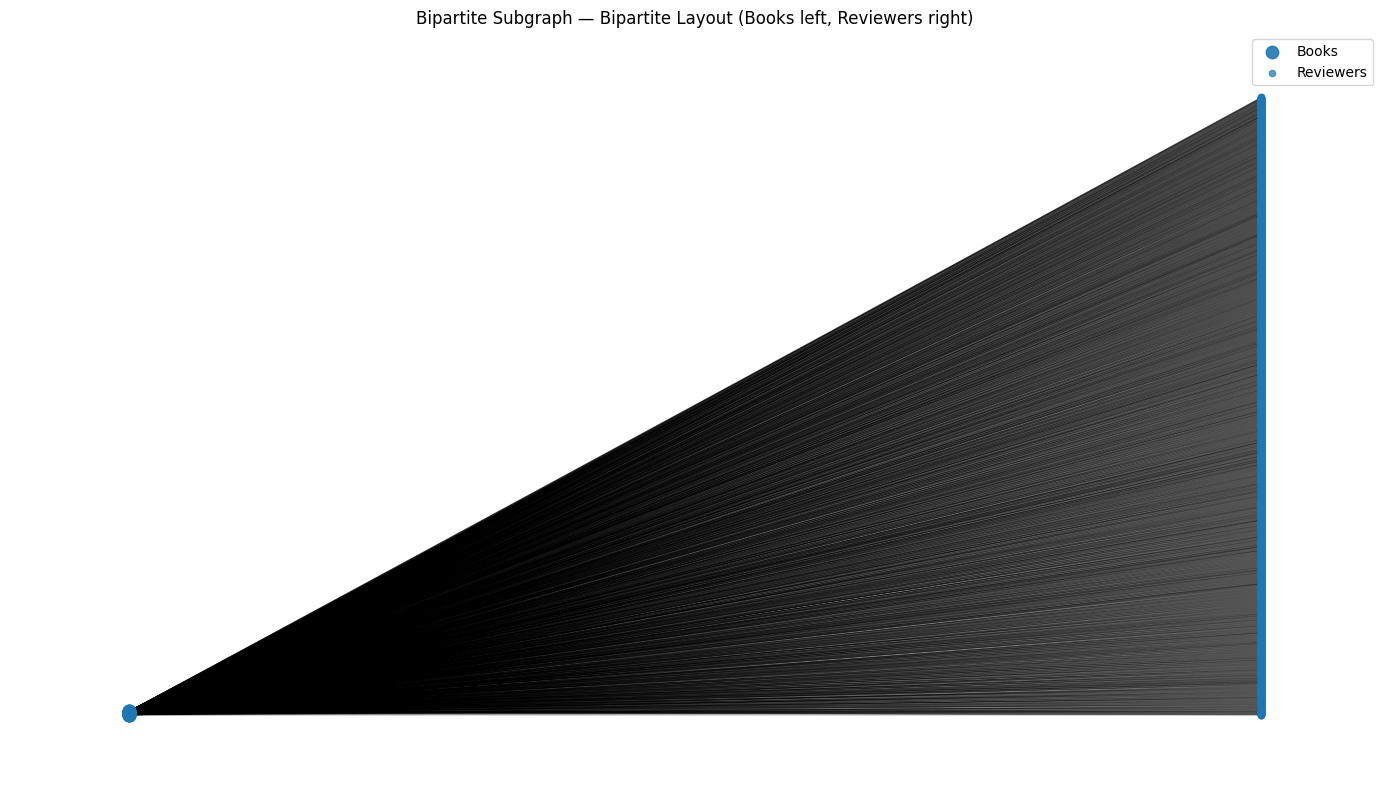

In [13]:
# --- 4) Bipartite layout (Books left, Reviewers right) ---
plt.figure(figsize=(14,8))
pos2 = {}

book_list = list(book_set)
user_list = [n for n in subB.nodes() if n not in book_set]

for i, b in enumerate(book_list):
    pos2[b] = (0, i)

for j, u in enumerate(user_list):
    pos2[u] = (1, j)

nx.draw_networkx_nodes(subB, pos2, nodelist=book_list, node_size=80, alpha=0.9, label="Books")
nx.draw_networkx_nodes(subB, pos2, nodelist=user_list, node_size=20, alpha=0.7, label="Reviewers")
nx.draw_networkx_edges(subB, pos2, width=0.4, alpha=0.25)

plt.title("Bipartite Subgraph — Bipartite Layout (Books left, Reviewers right)")
plt.axis("off")
plt.legend()
plt.tight_layout()
plt.show()

### The full bipartite graph contains 419 book nodes, ~47k user nodes, and ~62k edges, which is too large to visualize clearly. I therefore visualized a subgraph induced by 30 randomly sampled books and their connected reviewers. This preserves the bipartite structure while enabling readable plotting and efficient exploration in NetworkX

### Task C: Build a (i) bipartite recommender system (ii) unipartite recommender system to recommend books to a reader. What is the logic of each recommender system? How is the bi-partite feature useful over a unipartite network in building a recommender system? Demonstrate with a couple of examples.

In [14]:
# Bipartite recommender
def recommend_bipartite_pagerank(B, user_id, book_nodes, top_k=10, alpha=0.85):
    user_id = str(user_id)
    if user_id not in B:
        return []

    personalization = {n: 0 for n in B.nodes()}
    personalization[user_id] = 1

    pr = nx.pagerank(B, alpha=alpha, personalization=personalization)

    user_books = set(B.neighbors(user_id))
    candidates = [(b, pr[b]) for b in book_nodes if b not in user_books]
    candidates.sort(key=lambda x: x[1], reverse=True)

    return candidates[:top_k]

In [15]:
# Unipartite recommender
def build_book_projection(B, book_nodes):
    # weighted projection: edge weight = # shared reviewers
    return bipartite.weighted_projected_graph(B, book_nodes)

def recommend_unipartite_itembased(G_books, B, user_id, top_k=10):
    user_id = str(user_id)
    if user_id not in B:
        return []

    user_books = set(B.neighbors(user_id))
    scores = {}

    for b in user_books:
        if b not in G_books:
            continue
        for nb, edata in G_books[b].items():
            if nb in user_books:
                continue
            w = edata.get("weight", 1)
            scores[nb] = scores.get(nb, 0) + w

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return ranked


### Logic behind the recommender systems

**Unipartite (Book Projection) Recommender**
1) Project bipartite graph onto books
2) Two books are connected if they share reviewers
3) Edge weight = number of shared reviewers
4) For a user:
    - Look at books they reviewed
    - Recommend books that are strongly connected (high shared reviewer count)
    - Score = sum of shared-reviewer weights

This is essentially item-based collaborative filtering.
It assumes: If many users who liked Book A also liked Book B, then Book B is a good recommendation for someone who liked Book A.

**Bipartite (Personalized PageRank) Recommender**
1) Use the full bipartite graph (users + books).
2) Start a random walk from the target user.
3) The walk alternates:
User → Book → User → Book → ...
4) Books receiving higher probability mass are ranked higher.

This captures indirect relationships and global graph structure, not just direct shared reviewers.
This is closer to a graph-based collaborative filtering model.

### Why Bipartite Is Useful Over Unipartite

1) Preserves structure: The bipartite model keeps both users and books, whereas projection collapses user–book–user relationships into simple book–book edges.
2) Captures multi-step influence: Bipartite diffusion incorporates indirect paths (User -> Book -> User -> Book), enabling broader recommendations.
3) Less popularity-biased: Random-walk diffusion distributes influence through network structure rather than relying purely on shared-review counts.
4) Finds less obvious connections: Unipartite captures strong local similarity; bipartite incorporates global structural information.

The unipartite recommender captures strong local similarity (shared reviewers), whereas the bipartite recommender incorporates global structural information via random walks. This makes bipartite methods more flexible and often better at discovering less obvious but structurally relevant recommendations.

### Example where user reviewed multiple books

In [16]:
def pretty_print_recs(title, recs):
    print(f"\n{title}")
    print("-" * len(title))
    for i, (book, score) in enumerate(recs, 1):
        if isinstance(score, float):
            print(f"{i}. {book}\n   Score: {score:.6f}")
        else:
            print(f"{i}. {book}\n   Shared reviewers: {score}")
    print()


# Select example user
user_candidates = [u for u in users if B.degree(u) >= 5]
example_user = user_candidates[0]

G_books = build_book_projection(B, set(books))

print("="*60)
print(f"Example User: {example_user}")
print("="*60)

user_books = list(B.neighbors(example_user))
print("\nBooks Reviewed:")
for b in user_books[:10]:
    print("-", b)

# Generate recommendations
uni_recs = recommend_unipartite_itembased(G_books, B, example_user, top_k=5)
bi_recs = recommend_bipartite_pagerank(B, example_user, books, top_k=5)

pretty_print_recs("Unipartite (Book-Projection) Recommendations", uni_recs)
pretty_print_recs("Bipartite (Personalized PageRank) Recommendations", bi_recs)


Example User: 61221433

Books Reviewed:
- Fantasy Lover (Hunter Legends, #1)
- Fantasy of Frost (The Tainted Accords, #1)
- A Hidden Fire (Elemental Mysteries, #1)
- Dirty Little Secrets (J.J. Graves Mystery, #1)
- Southern Spirits (Southern Ghost Hunter Mysteries, #1)
- The Virgin Romance Novelist

Unipartite (Book-Projection) Recommendations
--------------------------------------------
1. Fantasy of Flight (The Tainted Accords, #2)
   Shared reviewers: 61
2. Fantasy of Freedom (The Tainted Accords, #4)
   Shared reviewers: 50
3. Fantasy of Fire (The Tainted Accords, #3)
   Shared reviewers: 50
4. Mystery Man (Dream Man, #1)
   Shared reviewers: 26
5. Wildest Dreams (Fantasyland, #1)
   Shared reviewers: 24


Bipartite (Personalized PageRank) Recommendations
-------------------------------------------------
1. Fantasy of Flight (The Tainted Accords, #2)
   Score: 0.008134
2. Fantasy of Freedom (The Tainted Accords, #4)
   Score: 0.006893
3. Fantasy of Fire (The Tainted Accords, #3)
  

#### Comparison between both recommender systems

In [17]:
print("="*60)
print("Comparison of Top Recommendations")
print("="*60)

print("\nCommon recommendations in both systems:")
common = set([r[0] for r in uni_recs]) & set([r[0] for r in bi_recs])
for book in common:
    print("-", book)

print("\nBooks recommended only by Bipartite system:")
for book, _ in bi_recs:
    if book not in [r[0] for r in uni_recs]:
        print("-", book)

print("\nBooks recommended only by Unipartite system:")
for book, _ in uni_recs:
    if book not in [r[0] for r in bi_recs]:
        print("-", book)


Comparison of Top Recommendations

Common recommendations in both systems:
- Fantasy of Freedom (The Tainted Accords, #4)
- Mystery Man (Dream Man, #1)
- Fantasy of Fire (The Tainted Accords, #3)
- Fantasy of Flight (The Tainted Accords, #2)

Books recommended only by Bipartite system:
- Nine Rules to Break When Romancing a Rake (Love By Numbers, #1)

Books recommended only by Unipartite system:
- Wildest Dreams (Fantasyland, #1)


#### Interpretation

This shows both systems successfully detect series continuation.
However:

Bipartite recommends Nine Rules to Break When Romancing a Rake and Unipartite recommends Wildest Dreams. This shows that bipartite incorporates broader structural similarity through multi-step paths.

##**TASK-D**

Book projection nodes: 419
Book projection edges: 396
Largest CC nodes: 30
Largest CC edges: 72

Detected communities: 4
Top community sizes: [10, 9, 6, 5]
Modularity Q: 0.4899

Using K communities = 4
Community sizes: [10, 9, 6, 5]

Book community label counts (including -1 for unassigned):
{0: 10, 1: 9, 2: 6, 3: 5, -1: 389}

Top books per community (by weighted degree):

Community 0 (size=10):
   ('The Seven Dials Mystery (Superintendent Battle #2)', 219)
   ('N or M? (Tommy & Tuppence Mysteries, #3)', 189)
   ('A Caribbean Mystery (Miss Marple, #9)', 186)
   ('The Sittaford Mystery', 186)
   ('The Secret Adversary (Tommy and Tuppence Mysteries, #1)', 183)
   ('Partners in Crime (Tommy & Tuppence Mysteries, #2)', 164)
   ('The Mystery of the Blue Train (Hercule Poirot, #6)', 164)
   ('By the Pricking of My Thumbs (Tommy and Tuppence Mysteries, #4)', 152)
   ('The Red House Mystery', 50)
   ('The Regatta Mystery and Other Stories', 45)

Community 1 (size=9):
   ('The Mystery Guest (Mo

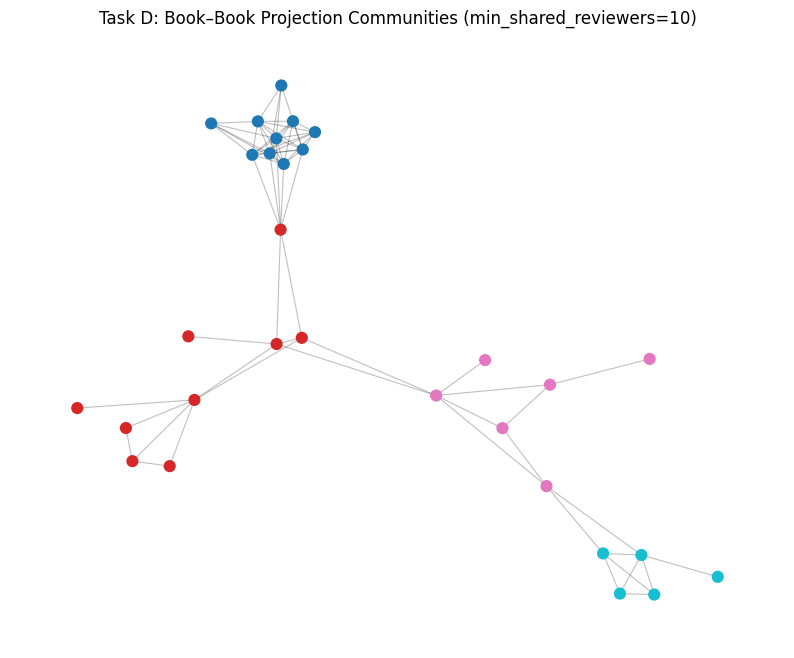

In [20]:
# ============================================================
# TASK D — Community Detection (3–4 communities) + Personalization
# Projection-based community detection on BOOK–BOOK graph
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
from collections import Counter, defaultdict

# --------------------------
# 0) Helper: get bipartite sets
# --------------------------
def get_bipartite_sets(B: nx.Graph):
    # If you tagged nodes with bipartite=0/1, use that.
    # Otherwise infer from df-based sets.
    top = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
    bottom = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 1}
    if top and bottom:
        return top, bottom
    # fallback: infer via df column values
    users = set(df["reviewer_id"].unique())
    books = set(df["book_title"].unique())
    # nodes may be stored as strings; normalize
    users2 = set(users) & set(B.nodes())
    books2 = set(books) & set(B.nodes())
    if users2 and books2:
        return users2, books2
    # last resort: assume smaller side is books (often 419) and larger is users (~47k)
    nodes = list(B.nodes())
    # use degree heuristic: users tend to have low degrees but far more nodes
    # Here choose by overlap with df unique sizes
    if len(set(df["book_title"].unique())) < len(set(df["reviewer_id"].unique())):
        books = set(df["book_title"].unique())
        users = set(df["reviewer_id"].unique())
        return (set(users) & set(nodes)), (set(books) & set(nodes))

    return set(nodes), set()  # should not happen


# --------------------------
# 1) Build BOOK–BOOK weighted projection
#    Weight = number of shared reviewers
# --------------------------
def build_book_projection_from_df(df: pd.DataFrame,
                                 user_col="reviewer_id",
                                 book_col="book_title",
                                 min_shared_reviewers=10):
    """
    Creates a book-book graph where edge weight = count of shared users.
    Uses efficient user->books aggregation; no need to use networkx projection.
    """
    # user -> list of books
    user_books = df.groupby(user_col)[book_col].apply(list)

    # count shared reviewers per book pair
    pair_counts = Counter()
    for books in user_books:
        # unique to avoid duplicate book entries per user
        uniq = list(dict.fromkeys(books))
        if len(uniq) < 2:
            continue
        uniq.sort()
        for i in range(len(uniq)):
            bi = uniq[i]
            for j in range(i + 1, len(uniq)):
                bj = uniq[j]
                pair_counts[(bi, bj)] += 1

    G = nx.Graph()
    # add all books as nodes
    all_books = df[book_col].unique().tolist()
    G.add_nodes_from(all_books)

    # add edges that meet the threshold
    for (b1, b2), w in pair_counts.items():
        if w >= min_shared_reviewers:
            G.add_edge(b1, b2, weight=w)

    return G


# ---- tune this to get ~3–4 communities cleanly ----
min_shared_reviewers = 10  # try 5/10/15/20

book_proj = build_book_projection_from_df(
    df,
    user_col="reviewer_id",
    book_col="book_title",
    min_shared_reviewers=min_shared_reviewers
)

print("Book projection nodes:", book_proj.number_of_nodes())
print("Book projection edges:", book_proj.number_of_edges())

# keep only largest connected component for cleaner community detection
if book_proj.number_of_edges() > 0:
    largest_cc = max(nx.connected_components(book_proj), key=len)
    book_proj_cc = book_proj.subgraph(largest_cc).copy()
else:
    book_proj_cc = book_proj.copy()

print("Largest CC nodes:", book_proj_cc.number_of_nodes())
print("Largest CC edges:", book_proj_cc.number_of_edges())


# --------------------------
# 2) Community Detection (Greedy Modularity)
# --------------------------
from networkx.algorithms.community import greedy_modularity_communities, modularity

if book_proj_cc.number_of_edges() == 0:
    raise ValueError("Projection graph has no edges. Lower min_shared_reviewers (e.g., 5).")

communities = list(greedy_modularity_communities(book_proj_cc, weight="weight"))
communities = sorted(communities, key=len, reverse=True)

print("\nDetected communities:", len(communities))
print("Top community sizes:", [len(c) for c in communities[:10]])

Q = modularity(book_proj_cc, communities, weight="weight")
print("Modularity Q:", round(Q, 4))


# --------------------------
# 3) Force EXACTLY 4 communities (as assignment asks 3–4)
#    Strategy:
#      - Keep 3 largest as-is
#      - Merge all remaining into the 4th bucket
# --------------------------
k = 4
if len(communities) <= k:
    communities_k = communities
else:
    communities_k = communities[:k-1]
    merged = set().union(*communities[k-1:])
    communities_k.append(merged)

communities_k = sorted(communities_k, key=len, reverse=True)

print("\nUsing K communities =", len(communities_k))
print("Community sizes:", [len(c) for c in communities_k])


# --------------------------
# 4) Attach community labels to books
# --------------------------
book_to_comm = {}
for idx, comm in enumerate(communities_k):
    for b in comm:
        book_to_comm[b] = idx

# books not in CC (isolated in projection) -> label -1
for b in book_proj.nodes():
    if b not in book_to_comm:
        book_to_comm[b] = -1

comm_counts = Counter(book_to_comm.values())
print("\nBook community label counts (including -1 for unassigned):")
print(dict(comm_counts))


# --------------------------
# 5) Show "representative" books per community
#    We'll use weighted degree within community as representativeness.
# --------------------------
def top_books_in_community(G: nx.Graph, comm_set: set, topn=10):
    sub = G.subgraph(comm_set)
    # weighted degree
    wdeg = sorted(sub.degree(weight="weight"), key=lambda x: x[1], reverse=True)
    return wdeg[:topn]


book_title = None
if "book_title" in df.columns:
    # Get unique book titles and create a dictionary mapping title to title
    unique_titles = df["book_title"].unique()
    book_title = {title: title for title in unique_titles}

print("\nTop books per community (by weighted degree):")
for i, comm in enumerate(communities_k):
    top_list = top_books_in_community(book_proj_cc, set(comm), topn=10)
    pretty = []
    for bid, score in top_list:
        name = book_title.get(bid, bid) if book_title else bid
        pretty.append((name, round(score, 2)))
    print(f"\nCommunity {i} (size={len(comm)}):")
    for item in pretty:
        print("  ", item)


# ============================================================
# 6) PERSONALIZATION: build user taste profile over communities
#    Then recommend books from the user's top community that they haven't read
# ============================================================

user_col = "reviewer_id"
book_col = "book_title"

# user -> set(read books)
user_read = df.groupby(user_col)[book_col].apply(set).to_dict()

# user -> community preference counts
user_comm_pref = {}
for u, books_read in user_read.items():
    comms = [book_to_comm.get(b, -1) for b in books_read]
    # ignore -1 if you want (books not in projection CC)
    comms = [c for c in comms if c != -1]
    user_comm_pref[u] = Counter(comms)

def recommend_from_top_community(user_id, n=10):
    if user_id not in user_read:
        return [], None  # Return empty list and None for top_comm

    pref = user_comm_pref.get(user_id, Counter())
    if not pref:
        # fallback: global popular by degree in projection CC
        global_rank = sorted(book_proj_cc.degree(weight="weight"), key=lambda x: x[1], reverse=True)
        recs = [b for b, _ in global_rank if b not in user_read[user_id]]
        return recs[:n], None  # Return recommendations and None for top_comm

    top_comm = pref.most_common(1)[0][0]
    candidate_books = list(communities_k[top_comm])

    # score candidates by weighted degree (popular within comm) + shared reviewer overlap heuristic
    sub = book_proj_cc.subgraph(candidate_books)
    wdeg = dict(sub.degree(weight="weight"))

    recs = [b for b in sorted(candidate_books, key=lambda b: wdeg.get(b, 0), reverse=True)
            if b not in user_read[user_id]]
    return recs[:n], top_comm

# ---- pick any user from your dataset for demo ----
sample_user = next(iter(user_read.keys()))
recs, top_comm = recommend_from_top_community(sample_user, n=10)

print("\nSample user:", sample_user)
print("Top community for user:", top_comm)
print("Recommendations (book_id / title):")
for b in recs:
    print("  -", book_title.get(b, b) if book_title else b)


# ============================================================
# 7) Visualize community-colored subgraph (small sample)
# ============================================================
import matplotlib.pyplot as plt
import random

# Take a sample of nodes from CC for visualization
viz_nodes = list(book_proj_cc.nodes())
if len(viz_nodes) > 150:
    viz_nodes = random.sample(viz_nodes, 150)

H = book_proj_cc.subgraph(viz_nodes).copy()

# color by community label
colors = []
for n in H.nodes():
    c = book_to_comm.get(n, -1)
    colors.append(c)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42, k=0.25)
nx.draw_networkx_nodes(H, pos, node_size=60, node_color=colors, cmap=plt.cm.tab10)
nx.draw_networkx_edges(H, pos, alpha=0.25, width=0.8)

plt.title(f"Task D: Book–Book Projection Communities (min_shared_reviewers={min_shared_reviewers})")
plt.axis("off")
plt.show()

Figure shows that the Community structure in the book–book projection network (min_shared_reviewers = 10). Nodes represent books and edges represent shared reviewers; colors indicate the four communities detected by greedy modularity maximization (Q = 0.4899).

##Interpretation:

To identify groups of related books, a weighted book–book projection of the bipartite reviewer–book network was constructed. In this projection, two books are connected if they share common reviewers, and edge weights represent the number of shared reviewers. To ensure meaningful similarity, only book pairs with at least 10 shared reviewers were retained.

The resulting projection contained 419 books and 396 edges. However, due to sparsity in reviewer overlap, only 30 books formed the largest connected component of the projection. Community detection was therefore performed on this connected subgraph.

Greedy modularity maximization was applied to detect communities. The algorithm identified four communities with sizes 10, 9, 6, and 5 books respectively. The modularity score of the partition was Q = 0.4899, indicating strong separation between communities and dense connectivity within communities. This confirms that the detected clusters represent structurally coherent groups of books.

Inspection of the books within each community shows clear thematic structure:

* **Community 0** consists primarily of classic detective and Golden-Age mystery titles (e.g., The Seven Dials Mystery, N or M?, The Sittaford Mystery), reflecting shared readership among fans of traditional mystery fiction.

* **Community 1** groups modern cozy mystery works (e.g., The Mystery Guest, Booked for Murder, The Mystery Writer), indicating a contemporary mystery readership cluster.

* **Community 2** contains contemporary romance titles (e.g., Summer Romance, Holiday Romance, One-Star Romance), forming a romance-focused reader community.

* **Community 3** includes historical or inspirational romance works (e.g., All That It Takes, Falling for You, Carolina Breeze), representing another distinct romance readership segment.

These communities correspond to recognizable genre-based reading preferences, demonstrating that shared reviewer behavior effectively captures thematic similarity between books.

The detected communities enable personalization by allowing recommendations to be generated within a reader’s dominant community. For each user, the distribution of previously reviewed books across communities is computed, and recommendations are drawn from the user’s most represented community while excluding already-read books. This approach leverages collective reading patterns to provide genre-consistent recommendations. If a user has no prior books within the detected communities, recommendations fall back to globally popular books in the projection.

Overall, the projection-based community detection reveals meaningful genre clusters within the book network and provides a principled basis for community-aware recommendation.